## **I. Libraries and Data**

In [3]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Sample Data
X, true_labels = make_blobs(n_samples=200, centers=3, random_state=42)
#We have 200 sample with 3 centroids

## **II. Data Exploratory**

### **1. First Scatter Plot**

In [6]:
# Def for 3 colors of 3 labels
def plot_original_data(X, true_labels):
    colors = ['r', 'g', 'b']  # 3 colors for 3 clusters
    plt.figure(figsize=(8, 6))
    for i in range(3):  # 3 clusters
        # Number of Cluster
        cluster_points = X[true_labels == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i}')
    plt.title("Original Data with True Clusters")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.legend()
    plt.show()

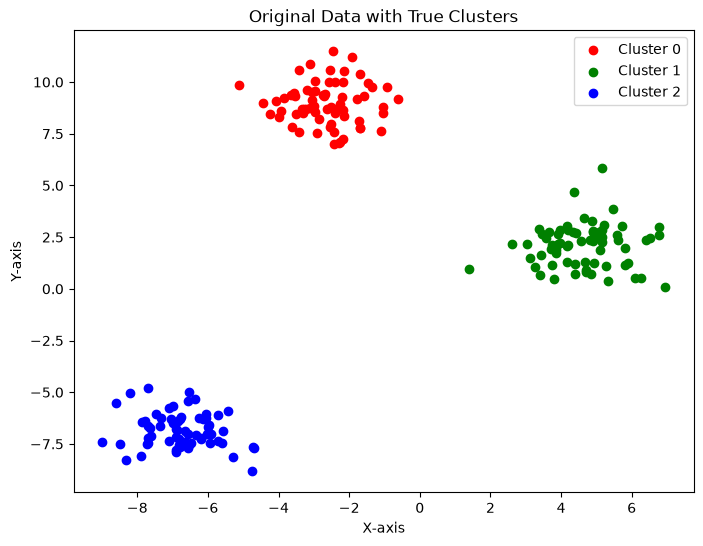

In [7]:
# Source Data with 3 colors
plot_original_data(X, true_labels)

### **2. Euclidean Def**

In [8]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1)

### Purpose:
Calculate the Euclidean distance between a single point 'a' and multiple points 'b' 
(usually cluster centroids).

### Parameters:
- a: A data point (vector, e.g., [x, y]).
- b: An array of points (usually cluster centroids, shape (k, n_features)).

### How it works:
- a - b: Subtract each element of 'a' from the rows of 'b', creating an array of shape (k, n_features).
- np.linalg.norm(..., axis=1): Calculate the Euclidean norm (distance) for each row, 
  returning an array of shape (k,) containing the distances from 'a' to each point in 'b'.

### Example:
If a = [1, 2] and b = [[3, 4], [5, 6]], the function returns the distances 
from 'a' to [3, 4] and.


### **3. K-Means Def**

In [9]:
def kmeans(X, k=3, max_iters=100):
    n_samples, n_features = X.shape
    centroids = X[np.random.choice(n_samples, k, replace=False)]
    converged = False
    inertia = 0

    for iteration in range(max_iters):
        # Temporarily set each point to nearest cluster
        clusters = [[] for _ in range(k)]
        for x in X:
            distances = euclidean_distance(x, centroids)
            cluster_idx = np.argmin(distances) #Take the shortest distance 
            clusters[cluster_idx].append(x)

        # Save the old for converged check
        previous_centroids = centroids.copy()
        # Re-calculate centroids
        for idx, cluster in enumerate(clusters):
            if cluster:
                centroids[idx] = np.mean(cluster, axis=0)

        # Convergence check
        if np.allclose(centroids, previous_centroids): 
            converged = True
            break

    # Tính inertia = total squared distances of each point to their centroid
    inertia = 0
    for idx, cluster in enumerate(clusters):
        cluster = np.array(cluster)
        inertia += np.sum((cluster - centroids[idx]) ** 2)

    return centroids, clusters, iteration+1, inertia

### Parameters:
- X: Input data (2D array, shape (n_samples, n_features)).
- k=3: Number of clusters (default is 3).
- max_iters=100: Maximum number of iterations to avoid an infinite loop.

### Initialization:
- n_samples, n_features = X.shape: Get the number of samples and features of the data.
- centroids = X[np.random.choice(n_samples, k, replace=False)]: Randomly select 'k' unique points from X as initial centroids (without replacement).
- converged = False: Boolean flag to check for convergence.
- inertia = 0: Sum of squared distances from points to their centroids (calculated later).

### Cluster Assignment:
- clusters = [[] for _ in range(k)]: Create an empty list for 'k' clusters.
- For each point 'x' in X:
    * Calculate the distance from 'x' to all centroids using 'euclidean_distance'.
    * np.argmin(distances): Find the index of the nearest centroid.
    * Assign 'x' to the corresponding cluster (clusters[cluster_idx]).

### Update Centroids:
- Save old centroids: Copy centroids to check for convergence later.
- Update centroids:
    * For each cluster, calculate the mean of all points in that cluster (np.mean(cluster, axis=0)).
    * Assign this mean value as the new centroid.
    * If the cluster is empty (if cluster), skip updating to avoid errors.

### Convergence Check:
- Compare new and old centroids using np.allclose (check if values are nearly identical).
- If no significant changes are detected, break the loop early.

### Calculate Inertia:
- Inertia: Total sum of squared distances from points in a cluster to their respective centroid.
- For each cluster:
    * Convert the cluster to a numpy array for vector operations.
    * Calculate the sum of squared distances from points to the centroid ((cluster - centroids[idx]) ** 2).
    * Accumulate the result into inertia.


### **4. Show data with Centroid**

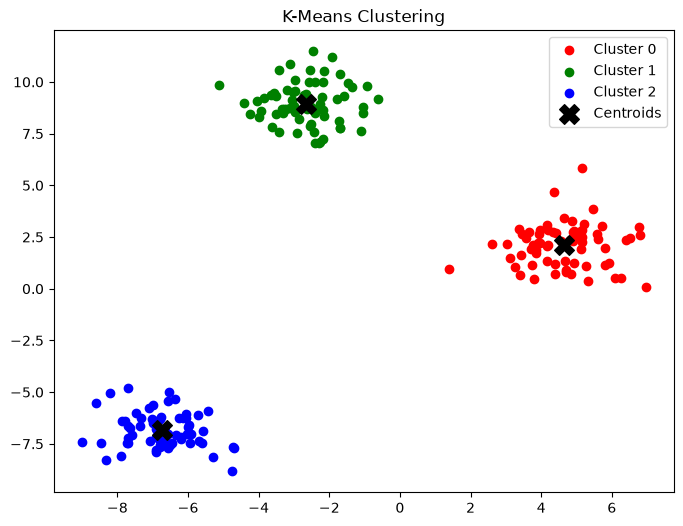

Convergence Loops: 8
Inertia (Total Squared Distance): 364.47


In [14]:
# Show K-Means
centroids, clusters, n_iters, inertia = kmeans(X, k=3)

def plot_clusters(clusters, centroids):
    colors = ['r', 'g', 'b']
    plt.figure(figsize=(8,6))
    for idx, cluster in enumerate(clusters):
        cluster = np.array(cluster)
        plt.scatter(cluster[:, 0], cluster[:, 1], color=colors[idx], label=f'Cluster {idx}')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
    plt.title("K-Means Clustering")
    plt.legend()
    plt.show()

plot_clusters(clusters, centroids)
print(f"Convergence Loops: {n_iters}")
print(f"Inertia (Total Squared Distance): {inertia:.2f}")

### Convergence Criteria in K-Means

To know when the cluster centroids in the K-Means algorithm converge, we need to understand how K-Means works and its stopping criteria. 
In K-Means, centroids are updated in each iteration, and the algorithm is considered converged when the centroids do not change 
(or change very little) between two consecutive iterations. 

Below is a detailed explanation of how to determine convergence, how it is implemented in code, and important notes.

#### 1. What is convergence in K-Means?
- Convergence occurs when:
    * The cluster centroids (centroids) do not change their positions between two consecutive iterations.
    * Or the assigned cluster for each data point no longer changes.
    * Or the objective function (inertia - the total sum of squared distances from points to their centroids) does not decrease significantly.
- In practice, K-Means usually checks the changes in centroids because if the centroids remain unchanged, the cluster labels of the points will not change either.

#### 2. How to check for convergence
- K-Means checks for convergence by comparing the centroids between two consecutive iterations:
- Save old centroids: After each assignment step and centroid update, save the positions of the previous centroids.
- Compare new and old centroids:
    * Calculate the distance (or difference) between the old and new centroids.
    * If the difference is smaller than a certain threshold or equal to 0, the algorithm stops.
- Stopping threshold:
    * A small threshold (e.g., 10^-4) is commonly used to check if the centroids are "nearly identical" to each other.
    * In the sklearn library, the np.allclose function is used to compare arrays with a specific precision.
- Maximum number of iterations:
    * To avoid an infinite loop, K-Means sets a maximum number of iterations (e.g., max_iters=100).
